In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import KFold
from sklearn.datasets import load_digits
from collections import Counter
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [2]:
# 加载数据（替代 MNIST 子集）
digits = load_digits()
X = digits.data      # 特征向量
y = digits.target    # 标签

In [3]:
X_train, X_test = X[:1500], X[1500:]
y_train, y_test = y[:1500], y[1500:]

In [4]:
# 3️⃣ 自定义 KNN
def myknn(sample, tr_feats, tr_label, k):
    distances = np.linalg.norm(tr_feats - sample, axis=1)
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = tr_label[k_indices]
    unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
    pred_label = unique_labels[np.argmax(counts)]
    return pred_label

In [5]:
# 4️⃣ 5折交叉验证函数
def cross_validation(X, y, k_values):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    avg_errors = []

    for k in k_values:
        fold_errors = []

        for train_index, val_index in kf.split(X):
            X_tr, X_val = X[train_index], X[val_index]
            y_tr, y_val = y[train_index], y[val_index]

            preds = []
            for sample in X_val:
                preds.append(myknn(sample, X_tr, y_tr, k))

            preds = np.array(preds)
            error = np.mean(preds != y_val)
            fold_errors.append(error)

        avg_error = np.mean(fold_errors)
        avg_errors.append(avg_error)
        print(f"k={k}, 平均错误率={avg_error:.4f}")

    return avg_errors

In [6]:
def cross_validation_knn(X, y, k_values):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    error_rates = []

    for k in k_values:
        errors = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            preds = [myknn(x, X_tr, y_tr, k) for x in X_val]
            error = np.mean(np.array(preds) != y_val)
            errors.append(error)
        error_rates.append(np.mean(errors))
        print(f"k={k}, 平均错误率={np.mean(errors):.4f}")
    
    return error_rates

k_values = range(1, 10)
error_rates = cross_validation_knn(X_train, y_train, k_values)

k=1, 平均错误率=0.0120
k=2, 平均错误率=0.0133
k=3, 平均错误率=0.0113
k=4, 平均错误率=0.0153
k=5, 平均错误率=0.0120
k=6, 平均错误率=0.0187
k=7, 平均错误率=0.0167
k=8, 平均错误率=0.0200
k=9, 平均错误率=0.0173


In [7]:
# 5️⃣ 尝试 k = 1 ~ 9
k_values = range(1, 10)
error_rates = cross_validation(X_train, y_train, k_values)

k=1, 平均错误率=0.0120
k=2, 平均错误率=0.0133
k=3, 平均错误率=0.0113
k=4, 平均错误率=0.0153
k=5, 平均错误率=0.0120
k=6, 平均错误率=0.0187
k=7, 平均错误率=0.0167
k=8, 平均错误率=0.0200
k=9, 平均错误率=0.0173


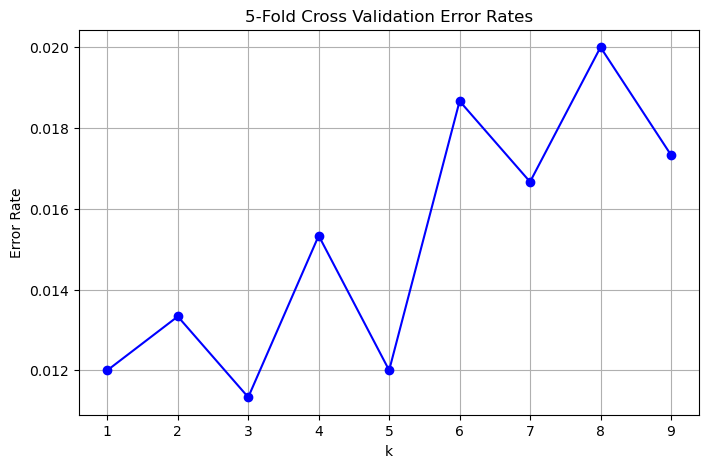

In [8]:
# 6️⃣ 绘制误差曲线
plt.figure(figsize=(8, 5))
plt.plot(k_values, error_rates, marker='o', color='b')
plt.title("5-Fold Cross Validation Error Rates")
plt.xlabel("k")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

In [9]:
# 7️⃣ 找出最佳 k
best_k = k_values[np.argmin(error_rates)]
print(f"\n✅ 最佳 k 值为: {best_k}")


✅ 最佳 k 值为: 3


In [10]:
# 6️⃣ 在测试集上预测
print("\n正在对测试集进行分类...")
y_pred = [myknn(x, X_train, y_train, best_k) for x in X_test]


正在对测试集进行分类...


In [11]:
# 7️⃣ 计算F1分数
f1_scores = f1_score(y_test, y_pred, average=None)
for digit, f1 in enumerate(f1_scores):
    print(f"Digit {digit}: F1-score = {f1:.4f}")

Digit 0: F1-score = 1.0000
Digit 1: F1-score = 0.9688
Digit 2: F1-score = 0.9818
Digit 3: F1-score = 0.9123
Digit 4: F1-score = 0.9524
Digit 5: F1-score = 0.9524
Digit 6: F1-score = 1.0000
Digit 7: F1-score = 0.9836
Digit 8: F1-score = 0.9286
Digit 9: F1-score = 0.9180


In [12]:
# 8️⃣ 输出详细分类报告
print("\n分类报告：")
print(classification_report(y_test, y_pred))


分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.94      1.00      0.97        31
           2       0.96      1.00      0.98        27
           3       0.96      0.87      0.91        30
           4       1.00      0.91      0.95        33
           5       0.91      1.00      0.95        30
           6       1.00      1.00      1.00        30
           7       0.97      1.00      0.98        30
           8       0.93      0.93      0.93        28
           9       0.93      0.90      0.92        31

    accuracy                           0.96       297
   macro avg       0.96      0.96      0.96       297
weighted avg       0.96      0.96      0.96       297



In [13]:
# 9️⃣ 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵：")
print(cm)

混淆矩阵：
[[27  0  0  0  0  0  0  0  0  0]
 [ 0 31  0  0  0  0  0  0  0  0]
 [ 0  0 27  0  0  0  0  0  0  0]
 [ 0  0  1 26  0  1  0  1  1  0]
 [ 0  0  0  0 30  0  0  0  1  2]
 [ 0  0  0  0  0 30  0  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 30  0  0]
 [ 0  2  0  0  0  0  0  0 26  0]
 [ 0  0  0  1  0  2  0  0  0 28]]


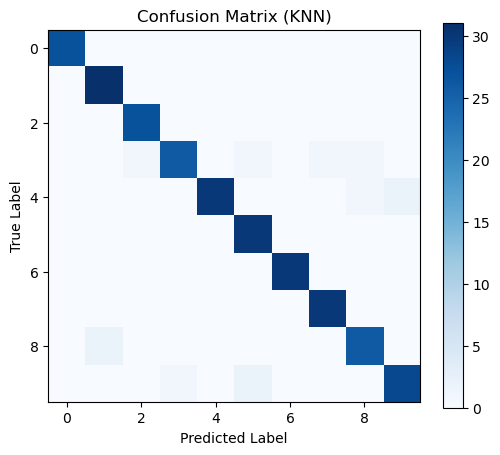

In [14]:
# 可视化混淆矩阵
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (KNN)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()